In [1]:
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats




In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url,index_col=0)

In [3]:
df.head(5)

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [6]:
df.nunique()

TV           190
radio        167
newspaper    172
sales        121
dtype: int64

In [7]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe().round(2)

,TV,radio,newspaper,sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


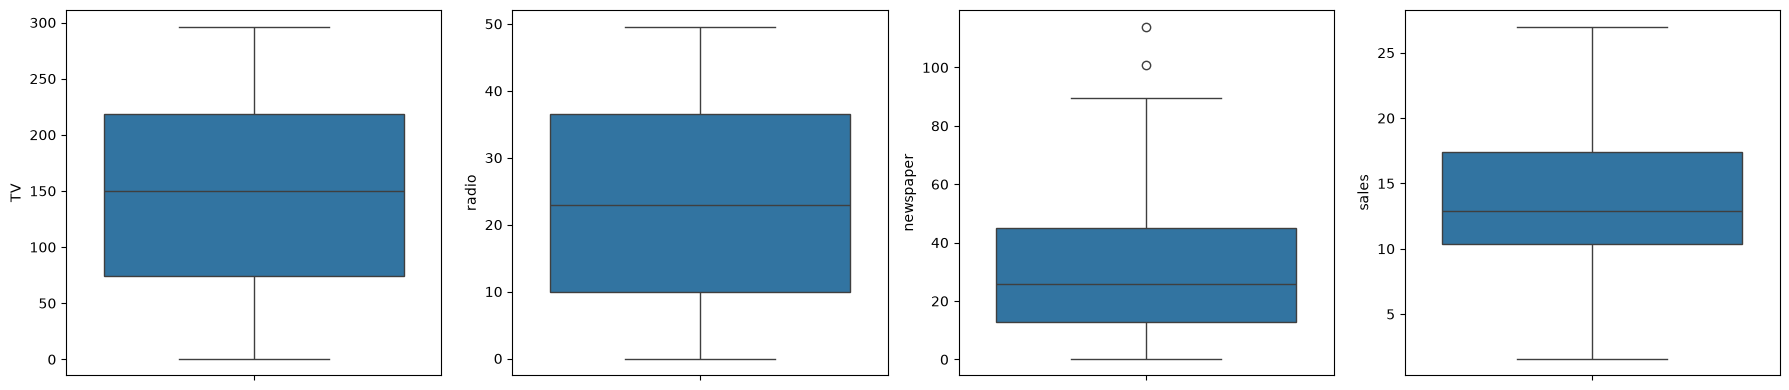

In [10]:
fig, axes = plt.subplots(1,4, figsize = (18,4))
for i, col in enumerate(['TV', 'radio', 'newspaper', 'sales']):
    sns.boxplot(y=col, data=df, ax=axes[i])

plt.tight_layout()

TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

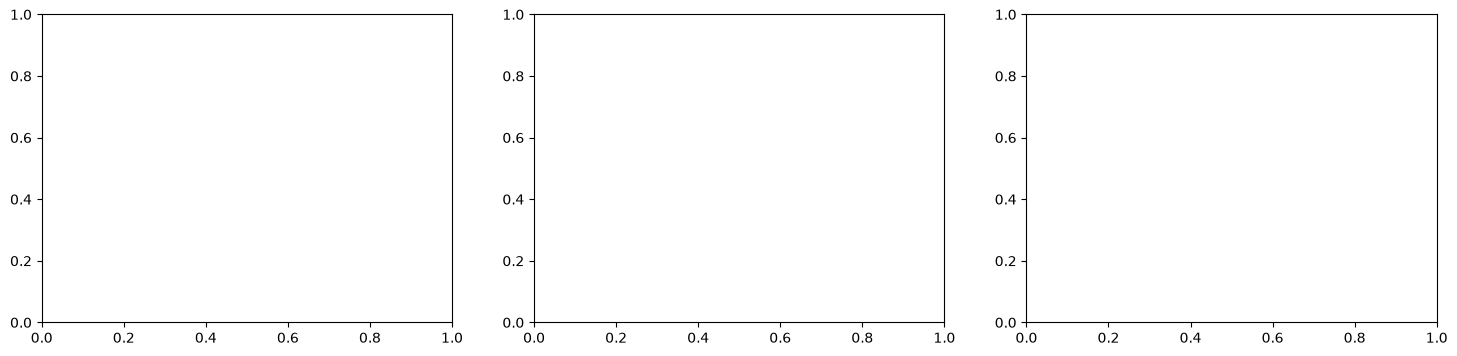

In [13]:

features =  df.columns[:-1]
target = df.columns[-1]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig, axes =  plt.subplot(1,3 , figsize=(18,4))
for i, features in enumerate(features):
    sns.regplot(x=df[features],y=df[target], ax=axes[i],color='green',line_kws={'color':'red'}) 
    axes[i].set_title(f'{features} vs {target}')
    axes[i].set_ylabel(target)
    axes[i].set_xlabel(features)
    

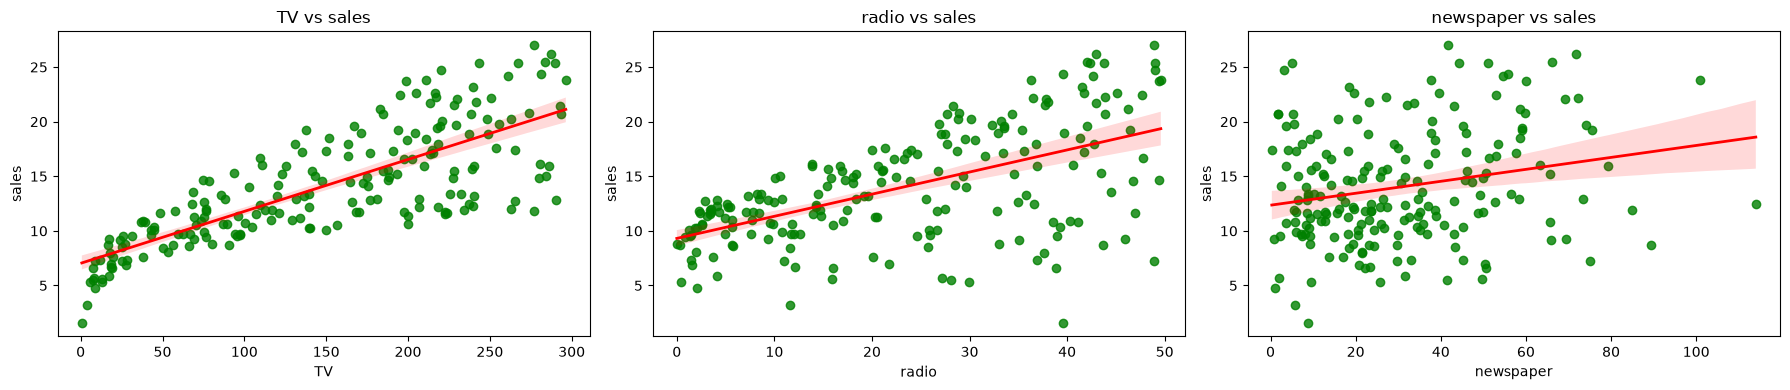

In [14]:
fig, axes = plt.subplots(1, len(features), figsize=(18, 4))

for ax, feature in zip(axes, features):
    sns.regplot(
        data=df,
        x=feature,
        y=target,
        ax=ax,
        color="green",
        line_kws={"color": "red", "linewidth": 2}
    )
    ax.set_title(f"{feature} vs {target}")

plt.tight_layout()

              TV  radio  newspaper  sales
TV         1.000  0.055      0.057  0.782
radio      0.055  1.000      0.354  0.576
newspaper  0.057  0.354      1.000  0.228
sales      0.782  0.576      0.228  1.000


Text(0.5, 1.0, 'Correlation Matrix')

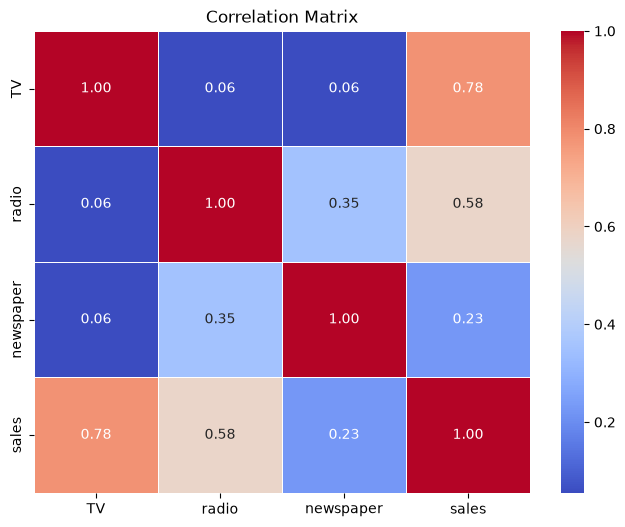

In [21]:
plt.figure(figsize=(8, 6))
corr = df.corr().round(3)
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")

Text(0.5, 1.02, 'Pairplot of Features and Target')

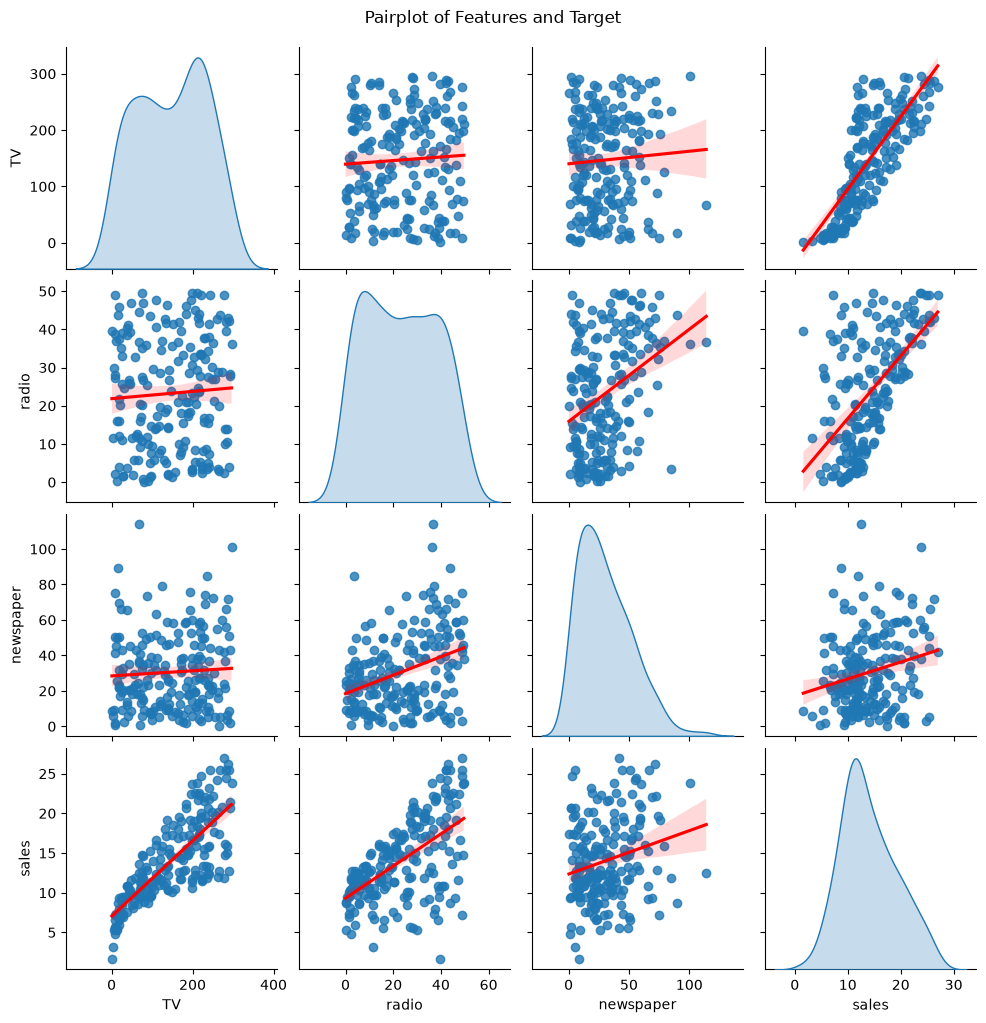

In [23]:
sns.pairplot(df, kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle("Pairplot of Features and Target", y=1.02)

In [32]:
x = df[['TV', 'radio', 'newspaper']]
y = df['sales']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [33]:
slr = LinearRegression()
slr.fit(x_train[['TV']], y_train)
y_pred_slr = slr.predict(x_test[['TV']])

In [34]:
print(y_pred_slr)

[14.81785392 16.30754437 20.83230507  7.78243112 17.46309864 10.72468577
 17.30067133  9.55984994 17.56055502 15.36546598  8.7013056   9.84757831
 18.12208943  7.49006196 13.71334823 15.13806775  7.57823679 16.40964153
 10.73396733 18.25667206 17.89005042 10.38590882  9.00295631 18.88317738
 10.44159818  9.72227724 17.14752559 13.70406667 11.28622018  7.62928537
 16.5117387  10.45087974 16.46997167  8.02375169 20.26612989 18.2937983
  9.48095667 19.94127527 12.67845424  8.51567439 12.62276488 15.45364081
  9.2396361  10.1306659  17.63480751  9.01223787 10.51585066 14.07532908
 12.09371593 10.78037513 10.86854996 15.05453371  7.64320771  7.60144069
 10.78501591 13.24462943 10.64579251 20.68380011  8.14905275 16.40964153]


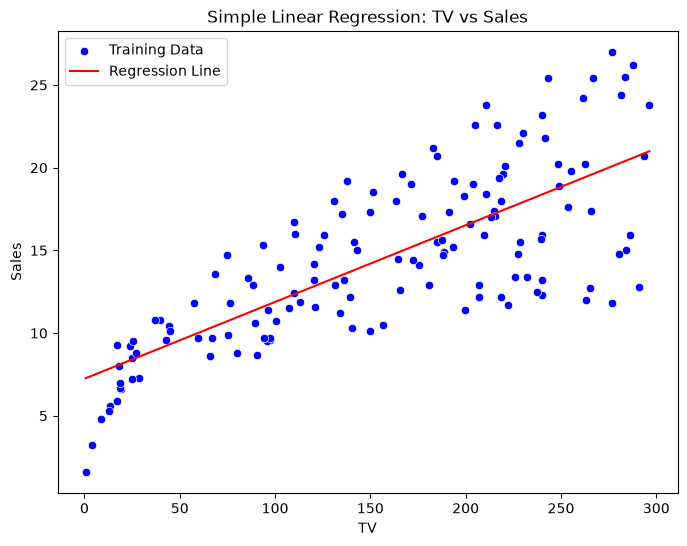

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_train['TV'], y=y_train, color='blue', label='Training Data')
sns.lineplot(x=x_train['TV'], y=slr.predict(x_train[['TV']]), color='red', label='Regression Line')
plt.title('Simple Linear Regression: TV vs Sales')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [39]:
mse_slr = mean_squared_error(y_test, y_pred_slr)
r2_slr = r2_score(y_test, y_pred_slr)
mae_slr = np.mean(np.abs(y_test - y_pred_slr))
print(f"Simple Linear Regression Metrics:")
print(f"MSE: {mse_slr:.4f}")
print(f"R2: {r2_slr:.4f}")
print(f"MAE: {mae_slr:.4f}")
print(f"R-sqaured: {r2_slr:.4f}")
 

Simple Linear Regression Metrics:
MSE: 8.9710
R2: 0.6714
MAE: 2.2759
R-sqaured: 0.6714


In [42]:
mlr = LinearRegression()
mlr.fit(x_train, y_train)
y_pred_mlr = mlr.predict(x_test)
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)
print("multiple linear regression metrics:")
print(f"MSE: {mse_mlr:.4f}")
print(f"R2: {r2_mlr:.4f}")
print(f"R-squared: {r2_mlr:.4f}")
#w1,w2,w3,b0
print(f"Weight 1: {mlr.coef_[0]:.4f}")
print(f"Weight 2: {mlr.coef_[1]:.4f}")
print(f"Weight 3: {mlr.coef_[2]:.4f}")
print(f"Bias: {mlr.intercept_:.4f}")

multiple linear regression metrics:
MSE: 3.7968
R2: 0.8609
R-squared: 0.8609
Weight 1: 0.0441
Weight 2: 0.1993
Weight 3: 0.0069
Bias: 2.7089


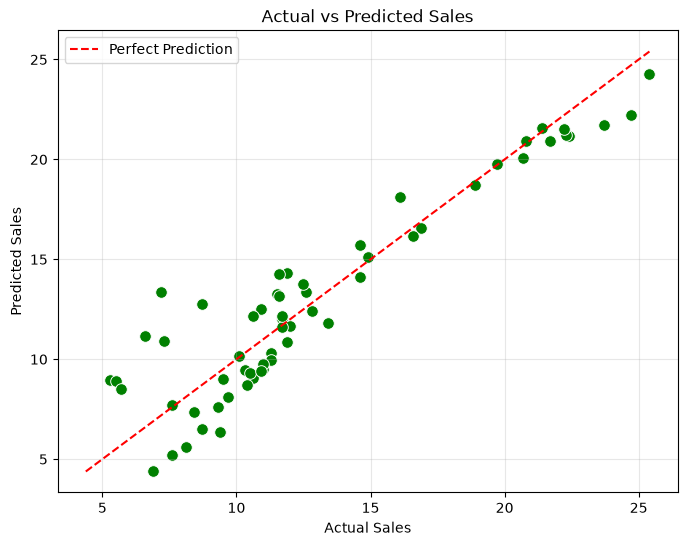

In [43]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred_mlr, color="green", s=70)

min_value = min(y_test.min(), y_pred_mlr.min())
max_value = max(y_test.max(), y_pred_mlr.max())
plt.plot([min_value, max_value], [min_value, max_value],
         color="red", linestyle="--", label="Perfect Prediction")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()